In [1]:
import numpy as np
import pandas as pd
import random
import copy
import matplotlib.pyplot as plt

In [2]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [3]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [4]:
df = pd.merge(df, beehives, on="year", how="inner")

In [5]:
df.head()

,year,week,honey,harvest,month,temp,wspd,prcp,pres,beehive
0,2019,30,66.0,1,7,18.468962,2.068542,0.125877,949.43176,92
1,2019,32,55.0,1,8,19.387705,1.972191,0.171244,948.63810,92
2,2019,33,134.0,2,8,16.821316,1.924085,0.108202,949.98334,92
3,2019,34,72.0,1,8,18.534908,1.906017,0.032221,957.32385,92
4,2019,35,59.0,1,8,20.535137,1.664818,0.082062,955.53265,92


Zakładamy, że wydajność pszczółki będzie zależeć od temperatury, prędkości wiatru, ilości opadu atmosferycznego, ciśnienia atmosferycznego oraz jej bazowej wydajności.

In [6]:
# parametry do późniejszej optymalizacji
params = {
    "temp_low": 10,
    "temp_high": 40,
    "temp_slope": 2.3,

    "wind_penalty": 0.3,

    "rain_penalty": 3.9,
    "rain_window": 20,

    "pres_penalty": 0.02,

    "base_efficiency": 1.0
}

In [7]:
def bee_efficiency(temp, wspd, prcp, pres, p):
    
    # jeżeli za ciepło lub za zimno - nie lata
    # załóżmy, że optymalna temperatura to 14 stopnie, a efektywność spada liniowo w miarę oddalania się od tej wartości
    
    temp_mid = (p["temp_low"] + p["temp_high"]) / 2
    temp_range = (p["temp_high"] - p["temp_low"]) / 2


    temp_eff = 1 - abs(temp - temp_mid) / temp_range
    temp_eff = np.clip(temp_eff, 0, 1)

    # if temp < p["temp_low"]:
    #     temp_eff = 0
    # elif temp > p["temp_high"]:
    #     temp_eff = 0
    # else:
    #     temp_eff = 1 - abs(temp - 14) / p["temp_slope"]
    #     temp_eff = max(0, temp_eff)

    # przy silnym wietrze pszczoły nie latają, zakładamy liniowy spadek efektywności wraz ze wzrostem prędkości wiatru
    wind_eff = 1 - p["wind_penalty"] * wspd
    wind_eff = np.clip(wind_eff, 0, 1)



    # taka sama logika przy opadach
    rain_eff = 1 - p["rain_penalty"] * prcp
    rain_eff = np.clip(rain_eff, 0, 1)

    pres_ref = 950
    pres_eff = 1 - p["pres_penalty"] * abs(pres - pres_ref)
    pres_eff = np.clip(pres_eff, 0, 1)


    eff = (0.45 * temp_eff + 0.20 * wind_eff + 0.25 * rain_eff +0.10 * pres_eff) #srednia wazona, zebysmy nie mialy tego problemu z zerem 
    eff = np.clip(eff, 0, 1)
    
    return eff

In [8]:
def simulate_honey(row, p):

    eff = bee_efficiency(
        row["temp"],
        row["wspd"],
        row["prcp"],
        row["pres"],
        p
    )

    honey = (
        row["beehive"] *
        eff *
        p["base_efficiency"] *
        row["harvest"]
    )

    return honey

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def loss(params_dict, df):

    preds = []

    for _, row in df.iterrows():
        preds.append(simulate_honey(row, params_dict))

    preds = np.array(preds)
    rmse = np.sqrt(np.mean((df["honey"].values - preds)**2))
    mae = mean_absolute_error(df["honey"].values, preds)

    return mae

In [10]:
def fitness(bee_params):
    return loss(bee_params, df)

In [11]:
def crossover(parent1, parent2):
    child = {}

    for key in parent1.keys():
        child[key] = parent1[key] if random.random() < 0.5 else parent2[key]

    return child

In [12]:
def random_bee():
    return {
        "temp_low": random.uniform(6, 10),
        "temp_high": random.uniform(20, 25),
        "temp_slope": random.uniform(0.5, 5.0),
        "wind_penalty": random.uniform(0.0, 1.0),
        "rain_penalty": random.uniform(0.0, 8.0),
        "pres_penalty": random.uniform(0.0, 0.05),
        "base_efficiency": random.uniform(0.5, 1.5)
    }

population = [random_bee() for _ in range(100)]

def mutate(bee, sigma=0.1):
    new_bee = copy.deepcopy(bee)

    key = random.choice(list(new_bee.keys()))
    new_bee[key] += random.gauss(0, sigma)

    return new_bee

def run_opt(population, iterations=200, elite_size=20, mutation_sigma=0.1):

    pop_size = len(population)

    for _ in range(iterations):
        population = sorted(population, key=fitness)

        new_population = []


        new_population.extend(population[:elite_size])
        while len(new_population) < pop_size:

            p1 = random.choice(population[:elite_size])
            p2 = random.choice(population[:elite_size])

            child = crossover(p1, p2)

            child = mutate(child, sigma=mutation_sigma)

            new_population.append(child)

        population = new_population

    return min(population, key=fitness)

In [13]:
population = [random_bee() for _ in range(100)]

In [ ]:
best_bee = run_opt(population, iterations=100)
best_bee
loss(best_bee, df)

{'temp_low': 5.508620873574145,
 'temp_high': 18.541953741447564,
 'temp_slope': 3.093657804717281,
 'wind_penalty': -0.07207388291037713,
 'rain_penalty': -0.12222207127177123,
 'pres_penalty': -0.15864597055700225,
 'base_efficiency': 1.636111748970597}

In [34]:
best_bee = {'temp_low': 7.6977352139378015, 'temp_high': 16.2896085184787, 'temp_slope': 2.465579368312372, 'wind_penalty': 0.7316157158432175, 'rain_penalty': -0.05973997110675208, 'pres_penalty': 0.023783050083484428, 'base_efficiency': 2.792350439233775}
best_rmse = loss(best_bee, df)

print("Najlepsze parametry:")
print(best_bee)

print(f"RMSE = {best_rmse:.4f}")

df["predicted_honey_best"] = [
    simulate_honey(row, best_bee) for _, row in df.iterrows()
]

Najlepsze parametry:
{'temp_low': 7.6977352139378015, 'temp_high': 16.2896085184787, 'temp_slope': 2.465579368312372, 'wind_penalty': 0.7316157158432175, 'rain_penalty': -0.05973997110675208, 'pres_penalty': 0.023783050083484428, 'base_efficiency': 2.792350439233775}
RMSE = 48.8663


{'temp_low': 7.6977352139378015, 'temp_high': 16.2896085184787, 'temp_slope': 2.465579368312372, 'wind_penalty': 0.7316157158432175, 'rain_penalty': -0.05973997110675208, 'pres_penalty': 0.023783050083484428, 'base_efficiency': 2.792350439233775}
RMSE = 70.8644

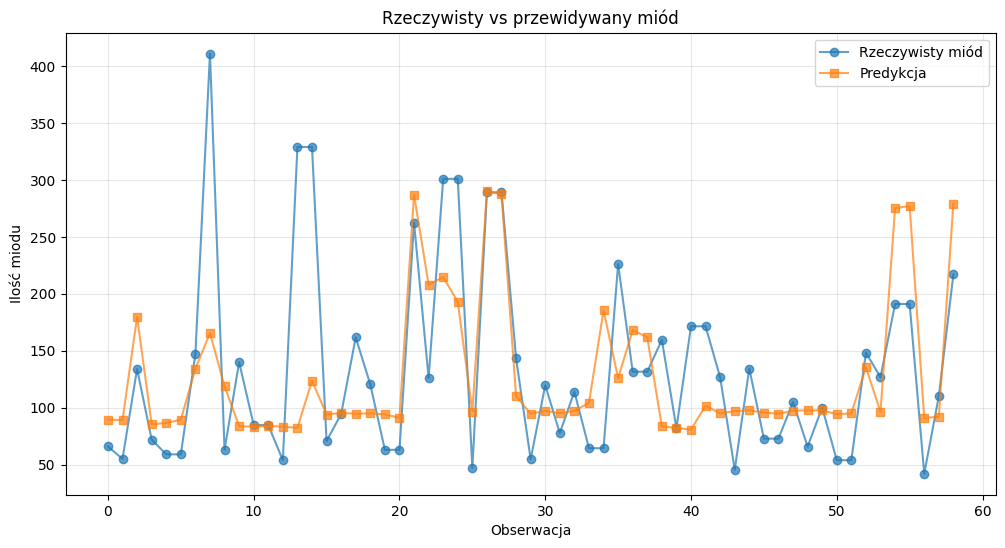

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(df["honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df["predicted_honey_best"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
import numpy as np
import pandas as pd

df_results = df.copy()

df_results["prediction"] = df_results.apply(
    lambda row: simulate_honey(row, best_bee),
    axis=1
)

df_results["difference"] = df_results["prediction"] - df_results["honey"]
df_results["absolute_error"] = abs(df_results["difference"])

df_results["error_percent"] = (
    df_results["absolute_error"] / df_results["honey"] * 100
)

df_results["accuracy_percent"] = 100 - df_results["error_percent"]
df_results["accuracy_percent"] = df_results["accuracy_percent"].clip(lower=0)

In [41]:
harvest_table = df_results[[
    "year",
    "week",
    "beehive",
    "harvest",
    "honey",
    "prediction",
    "difference",
    "absolute_error",
    "error_percent",
    "accuracy_percent"
]].copy()

harvest_table = harvest_table.rename(columns={
    "honey": "actual_honey"
})

harvest_table = harvest_table.round(2)

harvest_table

,year,week,beehive,harvest,actual_honey,prediction,difference,absolute_error,error_percent,accuracy_percent
0,2019,30,92,1,66.0,89.57,23.57,23.57,35.71,64.29
1,2019,32,92,1,55.0,89.08,34.08,34.08,61.97,38.03
2,2019,33,92,2,134.0,179.81,45.81,45.81,34.18,65.82
3,2019,34,92,1,72.0,85.44,13.44,13.44,18.67,81.33
4,2019,35,92,1,59.0,86.53,27.53,27.53,46.67,53.33
5,2019,35,92,1,59.0,89.44,30.44,30.44,51.59,48.41
6,2019,36,92,1,147.0,134.04,-12.96,12.96,8.82,91.18
7,2020,26,86,2,410.9,165.63,-245.27,245.27,59.69,40.31
8,2020,29,86,1,63.0,118.87,55.87,55.87,88.69,11.31
9,2020,30,86,1,140.0,83.77,-56.23,56.23,40.16,59.84


In [52]:
yearly_table = (
    df_results
    .groupby("year", as_index=False)
    .agg(
        actual_honey=("honey", "sum"),
        predicted_honey=("prediction", "sum")
    )
)

yearly_table["difference"] = yearly_table["predicted_honey"] - yearly_table["actual_honey"]
yearly_table["absolute_error"] = abs(yearly_table["difference"])

yearly_table["error_percent"] = (
    yearly_table["absolute_error"] / yearly_table["actual_honey"] * 100
)

yearly_table["accuracy_percent"] = 100 - yearly_table["error_percent"]
yearly_table["accuracy_percent"] = yearly_table["accuracy_percent"].clip(lower=0)

yearly_table = yearly_table.round(2)

yearly_table

,year,actual_honey,predicted_honey,difference,absolute_error,error_percent,accuracy_percent
0,2019,592.0,753.91,161.91,161.91,27.35,72.65
1,2020,1495.2,824.71,-670.49,670.49,44.84,55.16
2,2021,1563.8,1467.11,-96.69,96.69,6.18,93.82
3,2022,1489.6,1584.10,94.50,94.50,6.34,93.66
4,2023,847.7,678.27,-169.43,169.43,19.99,80.01
5,2024,979.3,1097.52,118.22,118.22,12.07,87.93
6,2025,877.8,1111.02,233.22,233.22,26.57,73.43


In [48]:
yearly_table = (
    df_results
    .groupby(["year", "beehive"], as_index=False)
    .agg(
        actual_honey=("honey", "sum"),
        predicted_honey=("prediction", "sum")
    )
)

yearly_table["actual_sum"] = yearly_table["actual_honey"] / yearly_table["beehive"]
yearly_table["predicted_sum"] = yearly_table["predicted_honey"] / yearly_table["beehive"]
yearly_table["difference"] = yearly_table["predicted_sum"] - yearly_table["actual_sum"]
yearly_table = yearly_table.round(2)
yearly_table

,year,beehive,actual_honey,predicted_honey,actual_sum,predicted_sum,difference
0,2019,92,592.0,753.91,6.43,8.19,1.76
1,2020,86,1495.2,824.71,17.39,9.59,-7.80
2,2021,98,1563.8,1467.11,15.96,14.97,-0.99
3,2022,100,1489.6,1584.10,14.90,15.84,0.94
4,2023,87,847.7,678.27,9.74,7.80,-1.95
5,2024,100,979.3,1097.52,9.79,10.98,1.18
6,2025,96,877.8,1111.02,9.14,11.57,2.43
